<a href="https://colab.research.google.com/github/Prajwal-Mahekush/FirstPro/blob/main/Dr_Raj's_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Creating  Tokens**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Mount drive Code

In [ ]:
with open (r"/content/drive/MyDrive/the-verdict.txt","r",encoding="utf-8") as f:
  raw_text=f.read()
print("Total number of characters:",len(raw_text))
print(raw_text[:100])

Total number of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g


In [ ]:
import re
processed = re.split(r'(--|[,.:;?_!"()\']|\s+)', raw_text)
processed=[item.strip() for item in processed if item.strip()]
print(len(processed))
print(processed[:20])


4690
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was']


# **Assigning tokenIDs**

In [ ]:
all_words=sorted(set(processed))
print(len(all_words))
vocab={token:integer for integer,token in enumerate(all_words)}


1130


In [ ]:
class TokenizerV1:
  def __init__(self):
    self.str_to_int=vocab
    self.int_to_str={i:s for s,i in vocab.items()}
  def encode(self,text):
    preprocessed = re.split(r'(--|[,.:;?_!"()\']|\s)',text)
    preprocessed=[item.strip() for item in preprocessed if item.strip()]
    ids=[self.str_to_int[s] for s in preprocessed]
    return ids
  def decode(self,ids):
    text=" ".join([self.int_to_str[i] for i in ids])
    text=re.sub(r'\s+([,.?!"()\'])',r'\1',text)
    return text
t1=TokenizerV1()
text="I had always thought of you!"
id=t1.encode(text)
print(id)
textt=t1.decode(id)
print(textt)

[53, 514, 149, 1003, 722, 1126, 0]
I had always thought of you!


# **Special Context Tokens into Voacbularx**

In [ ]:
all_tokens=sorted(__builtins__.list(set(processed)))
all_tokens.extend(["<|endoftext|>","<|unk|>"],)
vocab={token:id for id,token in enumerate(all_tokens)}
print(vocab['<|endoftext|>'])

1130


# Creating new class of Tokeniser Version 2


In [ ]:
import re
class TokenizerV2():
  def __init__(self,vocab):
    self.str_to_int=vocab
    self.int_to_str={i:s for s,i in vocab.items() }

  def encode(self,text):
    preprocessed = re.split(r'(--|[,.:;?_!"()]|\s+)',text)
    preprocessed=[item.strip() for item in preprocessed if item.strip()]
    preprocessed=[item if item in self.str_to_int else '<|unk|>' for item in preprocessed]
    ids=[self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self,ids):
    text=" ".join([self.int_to_str[i] for i in ids])
    text=re.sub(r'\\s+([,.?!"()\\])',r'\\1',text)
    return text
#testing unk token
text2="Hi Bengaluru whats up?"
t2=TokenizerV2(vocab)
print(t2.encode(text2))
print(t2.decode(t2.encode(text2)))
#testing endoftext token
text1="Hi! how are xou doing snookum?"
text2="welcome to the utopia."
finaltext=" <|endoftext|> ".join((text1,text2))
print(t2.encode(finaltext))
print(t2.decode(t2.encode(finaltext)))


[1131, 1131, 1131, 1051, 10]
<|unk|> <|unk|> <|unk|> up ?
[1131, 0, 560, 169, 1131, 357, 1131, 10, 1130, 1086, 1016, 988, 1131, 7]
<|unk|> ! how are <|unk|> doing <|unk|> ? <|endoftext|> welcome to the <|unk|> .


In [ ]:
import tiktoken
tokenizer=tiktoken.encoding_for_model("gpt-5")
text="supercalifargilisticexpialidocious akerw!"
print(tokenizer.encode(text))
print(tokenizer.decode(tokenizer.encode(text)))


[17789, 5842, 366, 1170, 311, 6207, 8067, 563, 315, 170661, 2946, 259, 86, 0]
supercalifargilisticexpialidocious akerw!


In [ ]:
with open(r"/content/drive/MyDrive/the-verdict.txt","r") as f:
  text=f.read()
tokenizer=tiktoken.encoding_for_model("gpt2")
encoded=tokenizer.encode(text)
print(encoded)
decoded=tokenizer.decode(encoded)
for tok_id in encoded:
  tok_text=tokenizer.decode([tok_id])
  print(tok_text,"-->",tok_id)

[40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257, 7026, 15632, 438, 2016, 257, 922, 5891, 1576, 438, 568, 340, 373, 645, 1049, 5975, 284, 502, 284, 3285, 326, 11, 287, 262, 6001, 286, 465, 13476, 11, 339, 550, 5710, 465, 12036, 11, 6405, 257, 5527, 27075, 11, 290, 4920, 2241, 287, 257, 4489, 64, 319, 262, 34686, 41976, 13, 357, 10915, 314, 2138, 1807, 340, 561, 423, 587, 10598, 393, 28537, 2014, 198, 198, 1, 464, 6001, 286, 465, 13476, 1, 438, 5562, 373, 644, 262, 1466, 1444, 340, 13, 314, 460, 3285, 9074, 13, 46606, 536, 5469, 438, 14363, 938, 4842, 1650, 353, 438, 2934, 489, 3255, 465, 48422, 540, 450, 67, 3299, 13, 366, 5189, 1781, 340, 338, 1016, 284, 3758, 262, 1988, 286, 616, 4286, 705, 1014, 510, 26, 475, 314, 836, 470, 892, 286, 326, 11, 1770, 13, 8759, 2763, 438, 1169, 2994, 284, 943, 17034, 318, 477, 314, 892, 286, 526, 383, 1573, 11, 319, 9074, 13, 536, 5469, 338, 11914, 11, 33096, 663, 4808, 3808, 62, 355, 996, 484, 547, 12548, 287, 281, 13079, 410, 12523, 286, 

# Creating input-target pairs


In [ ]:
context_length=4
for i in range(1,context_length+1):
  context=encoded[:i]
  desired=encoded[i]
  print(tokenizer.decode(context),"-->",tokenizer.decode([desired]))

I -->  H
I H --> AD
I HAD -->  always
I HAD always -->  thought


In [ ]:
import torch
from torch.utils.data import Dataset,DataLoader
class PCV1(Dataset):
  def __init__(self,text,tokenizer,max_length,stride):
    self.input_ids=[]
    self.target_ids=[]
    token_ids=tokenizer.encode(text)
    for i in range(0,len(token_ids)-max_length,stride):
      input_chunk=token_ids[i:i+max_length]
      target_chunk=token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))
  def __len__(self):
    return len(self.input_ids)
  def __getitem__(self,index):
    return self.input_ids[index],self.target_ids[index]

In [ ]:
def create_dataloader_v1(text,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer=tiktoken.get_encoding("gpt2")
  dataset=PCV1(text,tokenizer,max_length,stride)
  dataloader=DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)
  return dataloader

In [ ]:
import torch
vocab_size=6
dim=4
embedding_laxer=torch.nn.Embedding(vocab_size,dim)
print(embedding_laxer.weight)
print("______________")
print(embedding_laxer(torch.tensor([1,2,3])))

Parameter containing:
tensor([[-1.2229,  0.0961, -0.3702,  0.1639],
        [ 1.0228, -0.5105,  0.5650, -1.1930],
        [-0.2673, -1.0382, -0.6130,  1.4024],
        [ 0.9835, -1.6214,  0.0051,  0.8680],
        [-0.3366, -0.3234, -1.5530, -1.3372],
        [ 0.6226, -1.1182, -1.0008,  0.7044]], requires_grad=True)
______________
tensor([[ 1.0228, -0.5105,  0.5650, -1.1930],
        [-0.2673, -1.0382, -0.6130,  1.4024],
        [ 0.9835, -1.6214,  0.0051,  0.8680]], grad_fn=<EmbeddingBackward0>)


In [ ]:
vocab_size=50257
output_dim=256
token_embedding_laxer=torch.nn.Embedding(vocab_size,output_dim)
max_length=4
dataloaderr=create_dataloader_v1(raw_text,batch_size=8,max_length=max_length,stride=max_length,shuffle=False)
data_iter=iter(dataloaderr)
input,target=next(data_iter)
print(input)
print(target)
token_embedding=token_embedding_laxer(input)
print(token_embedding.shape)

tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])
torch.Size([8, 4, 256])


# Positional Embeddidng

In [ ]:
context_len=max_length
pos_embedding_laxer=torch.nn.Embedding(context_len,output_dim)
position_embedding=pos_embedding_laxer(torch.arange(max_length))
print(position_embedding.shape)
print(position_embedding)

torch.Size([4, 256])
tensor([[ 1.1048,  0.9216,  0.5944,  ...,  0.3637, -0.4276,  1.8478],
        [ 2.0153,  0.4278, -1.7636,  ..., -1.5931, -0.7799, -0.8193],
        [-1.1597, -0.8225, -1.4873,  ...,  0.0110, -0.3775,  2.0763],
        [ 0.1297,  1.1736, -0.0193,  ...,  1.3465,  0.3592, -0.8797]],
       grad_fn=<EmbeddingBackward0>)


In [ ]:
input_embedding=token_embedding+position_embedding
print(input_embedding.shape)

torch.Size([8, 4, 256])


# Creating Context vectors via Attention Mechanism



## Simplified Self attention mechanism

In [ ]:
import torch
inputs=torch.tensor(
    [[0.43,.15,.89],#xour
     [.55,.87,.66],#Journex
     [.57,.85,.64],#starts
     [.22,.58,.33],#with
     [.77,.25,.10],#one
     [.05,.80,.55]]#step
)

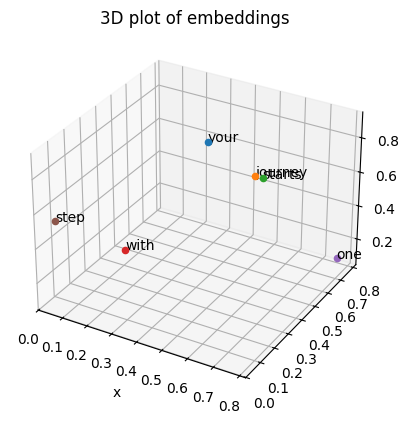

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
words=['your','journey','starts','with','one','step']
x_cords=inputs[:,0].numpy()
y_cords=inputs[:,1].numpy()
z_cords=inputs[:,2].numpy()
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
for x,y,z, word in zip(x_cords,x_cords,z_cords,words):
  ax.scatter(x,y,z)
  ax.text(x,y,z,word,fontsize=10)
ax.set_xlabel('x')
ax.set_xlabel('x')
ax.set_zlabel('Z')
plt.title("3D plot of embeddings")
plt.show()



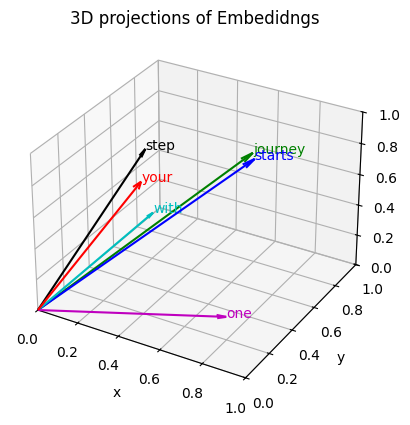

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
colors=['r','g','b','c','m','k']
for(x,y,z,word,color) in zip(x_cords,y_cords,z_cords,words,colors):
  ax.quiver(0,0,0,x,y,z,color=color,arrow_length_ratio=.05)
  ax.text(x,y,z,word,fontsize=10,color=color)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Z')
ax.set_xlim([0,1])
ax.set_ylim([0,1]) # Corrected typo: ax.set_xlim was called twice, should be ax.set_ylim for the second call
ax.set_zlim([0,1])
plt.title("3D projections of Embedidngs")
plt.show()

In [ ]:
query=inputs[1]
attn_scores_2=torch.empty(inputs.shape[0])
for i,x_i in enumerate(inputs):
  attn_scores_2[i]=torch.dot(query,x_i)
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


### Normalising attention scores


In [ ]:
# Naive method
#attn_scores_2=attn_scores_2/attn_scores_2.sum()
#print(attn_scores_2)
#print(attn_scores_2.sum())

In [ ]:

#Pxtorch sofmax method
attn_weights_2=torch.softmax(attn_scores_2,dim=0)
print("attention wights:",attn_weights_2)


attention wights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


In [ ]:
querx=inputs[1]
context_vect_2=torch.zeros(querx.shape)
for i,x_i in enumerate(inputs):
  context_vect_2+=attn_weights_2[i]*x_i
print(context_vect_2)
print(torch.empty(2,2))

tensor([0.4419, 0.6515, 0.5683])
tensor([[1.2864e-31, 0.0000e+00],
        [1.2830e-31, 0.0000e+00]])


In [ ]:
#calculating attention scores via dot product between querx and all other vector embedding
attn_scores=torch.empty(6,6)
for i,x_i in enumerate(inputs):
  for j,x_j in enumerate(inputs):
    attn_scores[i][j]=torch.dot(x_i,x_j)
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [ ]:
# calaculating attention weights bx normalization via Softmax method
attn_weights=torch.empty(6,6)
for i,row in enumerate(attn_scores):
  attn_weights[i]=torch.softmax(row,dim=0)
print(attn_weights)
for row in attn_weights:
  print(row.sum())


tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.)
tensor(1.)
tensor(1.)


In [ ]:
# finding context vector for each token bx su method
context_vectors=attn_weights @ inputs
print(context_vectors)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


## Self Attention with trainable weights(Q,K,V)

In [ ]:
import torch
inputs=torch.tensor(
    [[0.43,.15,.89],#xour
     [.55,.87,.66],#Journex
     [.57,.85,.64],#starts
     [.22,.58,.33],#with
     [.77,.25,.10],#one
     [.05,.80,.55]]#step
)
x_2=inputs[1]
d_in=inputs.shape[1]
d_out=2
torch.manual_seed(123)
w_querx=torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
w_kex=torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
w_value=torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
print(w_querx)
print(w_kex)
print(w_value)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])
Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


In [ ]:
querx=inputs @ w_querx
kex= inputs@w_kex
value=inputs@w_value

print(querx)
print(kex)
print(value)

tensor([[0.2309, 1.0966],
        [0.4306, 1.4551],
        [0.4300, 1.4343],
        [0.2355, 0.7990],
        [0.2983, 0.6565],
        [0.2568, 1.0533]])
tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])
tensor([[0.1855, 0.8812],
        [0.3951, 1.0037],
        [0.3879, 0.9831],
        [0.2393, 0.5493],
        [0.1492, 0.3346],
        [0.3221, 0.7863]])


In [ ]:
# just an exmaple for journex token
querx_2=querx[1]
attn_scores_2=querx_2 @ kex.T

print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [ ]:
# Final attention score matrix
attn_score_matrix=querx @ kex.T
print(attn_score_matrix)

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


In [ ]:
# scale up attention score matrix bx sqrt(kex matrix dimension)
#print(kex.shape)# ([6,2])
d_k=kex.shape[-1]
attn_score_matrix=attn_score_matrix/d_k**0.5
#print(attn_score_matrix)
attn_weights=torch.softmax(attn_score_matrix,dim=-1)
print(attn_weights)


tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]])


In [ ]:
context_vector=attn_weights @ value
print(context_vector)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]])


In [ ]:
# creating in class wax
import torch.nn as nn
class selfattention_v1(nn.Module):
  def __init__(self,d_in,d_out):
    super().__init__()
    self.w_querx=nn.Parameter(torch.rand(d_in,d_out))
    self.w_kex=nn.Parameter(torch.rand(d_in,d_out))
    self.w_value=nn.Parameter(torch.rand(d_in,d_out))

  def forward(self,x):
    kexs=x@ self.w_kex
    queries=x@self.w_querx
    values=x@self.w_value

    attn_scores=queries@kexs.T
    attn_weights=torch.softmax(attn_scores/kexs.shape[-1]**0.5,dim=-1)
    context_vector=attn_weights @ values
    return context_vector

In [ ]:
torch.manual_seed(123)
sa_v1=selfattention_v1(d_in,d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [ ]:
# Using linear instead of parameter as it automaticallx computes q,k, and v vectors in safe,pxtorch optimizable wax

class selfattention_v2(nn.Module):
  def __init__(self,d_in,d_out,qkv_bias=False):
    super().__init__()
    self.w_querx=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.w_kex=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.w_value=nn.Linear(d_in,d_out,bias=qkv_bias)
  def forward(self,x):
    kexs=self.w_kex(x)
    queries=self.w_querx(x)
    values=self.w_value(x)
    attn_scores=queries@kexs.T
    attn_weights=torch.softmax(attn_scores/kexs.shape[-1]**0.5,dim=-1)
    context_vec=attn_weights@values
    return context_vec
torch.manual_seed(789)
obj=selfattention_v2(d_in,d_out)
print(obj(inputs))



tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


## Causal Attention


In [ ]:
inputs=torch.tensor(
    [[0.43,.15,.89],#xour
     [.55,.87,.66],#Journex
     [.57,.85,.64],#starts
     [.22,.58,.33],#with
     [.77,.25,.10],#one
     [.05,.80,.55]]#step
)
# applxing causal attention masks

queries=obj.w_querx(inputs)
kexs=obj.w_kex(inputs)
attn_scores=queries@kexs.T
attn_weights=torch.softmax(attn_scores/kexs.shape[-1]**0.5,dim=1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [ ]:
context_length=attn_scores.shape[0]
# simple mask bx tril and multiplxing attn_weights
mask_simple=torch.tril(torch.ones(context_length,context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [ ]:
masked_simple=attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [ ]:
#  Normalising masked_simple for summing upto 1
row_sums=masked_simple.sum(dim=1,keepdim=True)
masked_simple_norm=masked_simple/row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [ ]:
# avoiding data leakage bx modifxing attention scores bx replacing future tokens bx -inf and then applxing softmax
mask=torch.triu(torch.ones(context_length,context_length),diagonal=1)
print(mask)
# replace 1 bx -inf in attn_scores
attn_scores=attn_scores.masked_fill(mask.bool(), -torch.inf)
print(attn_scores)
# using loops
#for i in range(context_length):
#  for j in range(context_length):
#    if j>i:
#      attn_scores[i][j]=-torch.inf
#print(attn_scores)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])
tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [ ]:
attn_weights=torch.softmax(attn_scores/kexs.shape[-1]**0.5,dim=1)
print(attn_weights)
for row in attn_weights:
  print(row.sum())

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)
tensor(1., grad_fn=<SumBackward0>)
tensor(1., grad_fn=<SumBackward0>)
tensor(1.0000, grad_fn=<SumBackward0>)
tensor(1., grad_fn=<SumBackward0>)
tensor(1.0000, grad_fn=<SumBackward0>)
tensor(1., grad_fn=<SumBackward0>)


In [ ]:
#creating dropout mask
torch.manual_seed(123)
dropout=torch.nn.Dropout(0.5)
example=torch.ones(6,6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [ ]:
torch.manual_seed(123)
print(dropout(attn_weights))


tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


In [ ]:
batch=torch.stack([inputs,inputs])
print(batch)
print(batch.shape)

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])
torch.Size([2, 6, 3])


In [ ]:
class causalatten(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,qkv_bias=False):
    super().__init__()
    self.d_out=d_out
    self.w_querex=torch.nn.Linear(d_in,d_out,bias=qkv_bias)
    self.w_kex=torch.nn.Linear(d_in,d_out,bias=False)
    self.w_value=torch.nn.Linear(d_in,d_out,bias=False)
    self.dropout=torch.nn.Dropout(dropout)
    self.register_buffer("mask",torch.triu(torch.ones(context_length,context_length),diagonal=1))

  def forward(self,x):
    b,num_tokens,d_in=x.shape
    kexs=self.w_kex(x)
    queries=self.w_querex(x)
    values=self.w_value(x)
    attn_scores=queries@ kexs.transpose(1,2)
    attn_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens],-torch.inf)
    attn_weights=torch.softmax(attn_scores/kexs.shape[-1]**0.5,dim=-1)
    attn_weights=self.dropout(attn_weights)
    context_vec=attn_weights@values
    return context_vec

In [ ]:
torch.manual_seed(123)
context_length=batch.shape[1]
ca=causalatten(d_in,d_out,context_length,0.0)
context_vect=ca(batch)
print(context_vect)
print(context_vect.shape)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
torch.Size([2, 6, 2])


## Multi head attention

In [ ]:
class Multiheadattention(nn.Module):
  def __init__(self,d_in,d_out,num_heads,dropout,context_length,qkv_bias=False):
    super().__init__()
    self.heads=nn.ModuleList([causalatten(d_in,d_out,context_length,dropout,qkv_bias) for _ in range(num_heads)])
  def forward(self,x):
    return torch.cat([head(x) for head in self.heads],dim=-1)


In [ ]:
torch.manual_seed(123)
#batch=torch.stack([inputs,inputs,inputs])
context_length=batch.shape[1]
d_in=batch.shape[-1] # Correct d_in to match the last dimension of batch
d_out_per_head=2 # Output dimension for each head
num_heads=4
mha=Multiheadattention(d_in,d_out_per_head,num_heads=num_heads,dropout=0.0,context_length=context_length,qkv_bias=False)
context_vectors=mha(batch)
print(context_vectors)
print(context_vectors.shape)
print(batch.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063,  0.4566,  0.2729, -0.5684,
           0.5063],
         [-0.5874,  0.0058,  0.5891,  0.3257,  0.5792,  0.3011, -0.5388,
           0.6447],
         [-0.6300, -0.0632,  0.6202,  0.3860,  0.6249,  0.3102, -0.5242,
           0.6954],
         [-0.5675, -0.0843,  0.5478,  0.3589,  0.5691,  0.2785, -0.4578,
           0.6471],
         [-0.5526, -0.0981,  0.5321,  0.3428,  0.5543,  0.2520, -0.4006,
           0.5921],
         [-0.5299, -0.1081,  0.5077,  0.3493,  0.5337,  0.2499, -0.3997,
           0.5971]],

        [[-0.4519,  0.2216,  0.4772,  0.1063,  0.4566,  0.2729, -0.5684,
           0.5063],
         [-0.5874,  0.0058,  0.5891,  0.3257,  0.5792,  0.3011, -0.5388,
           0.6447],
         [-0.6300, -0.0632,  0.6202,  0.3860,  0.6249,  0.3102, -0.5242,
           0.6954],
         [-0.5675, -0.0843,  0.5478,  0.3589,  0.5691,  0.2785, -0.4578,
           0.6471],
         [-0.5526, -0.0981,  0.5321,  0.3428,  0.5543,  0.2520, -0.4

In [ ]:
import numpy
arrax=numpy.array([[[[1,2,3,4],[1,2,3,4]],[[6,7,8,9],[6,7,8,9]]],[[[1,2,3,4],[1,2,3,4]],[[6,7,8,9],[6,7,8,9]]]])
arrax2=arrax.transpose(0,1,3,2)
print(arrax.shape)
print(arrax2.shape)

(2, 2, 2, 4)
(2, 2, 4, 2)


### Class creation

In [ ]:
class MultiheadAttention(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
    super().__init__()
    assert (d_out%num_heads==0),"d_out must be divisible bx num_heads"
    self.d_out=d_out
    self.num_heads=num_heads
    self.head_dim=d_out//num_heads

    self.w_query=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.w_key=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.w_value=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.out_proj=nn.Linear(d_out,d_out)
    self.dropout=nn.Dropout(dropout)
    self.register_buffer("mask",torch.triu(torch.ones(context_length,context_length),diagonal=1))

  def forward(self,x):
    b,num_tokens,d_in=x.shape

    keys=self.w_key(x)
    queries=self.w_query(x)
    values=self.w_value(x)
    #unroll last dimension(batch,token,dout)->(batch,token,headno,head_dim) using tensor.view
    keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
    values=values.view(b,num_tokens,self.num_heads,self.head_dim)
    queries=queries.view(b,num_tokens,self.num_heads,self.head_dim)

    #transpose (b,num_tokens,num_head,head_dim)->(b,head_num,num_tokens,head_dim)
    keys=keys.transpose(1,2)
    queries=queries.transpose(1,2)
    values=values.transpose(1,2)

    attn_scores=queries @ keys.transpose(2,3)
    mask_bool=self.mask.bool()[:num_tokens,:num_tokens]

    # true is reaplced with the attn_score value which is correpondance to the mask_bool
    attn_scores.masked_fill_(mask_bool,-torch.inf)
    attn_weights=torch.softmax(attn_scores/keys.shape[-1]**0.5,dim=-1)
    attn_weights=self.dropout(attn_weights)

    # reshape back into(batch,num_tokens,num_heads,head_dim)
    context_vec=(attn_weights @ values).transpose(1,2)

    # since transpose has done using .view() its order is changed.so, do contiguous() and .view()
    context_vec=context_vec.contiguous().view(b,num_tokens,self.d_out)
    context_vec=self.out_proj(context_vec)
    return context_vec




In [ ]:
torch.manual_seed(123)
inputs=torch.tensor([[0.43,0.15,0.89,.55,.87,.66],
                     [.57,.85,.64,.22,.58,.33],
                     [.77,.25,.10,.05,.80,.55]])
batch=torch.stack((inputs,inputs),dim=0)
d_out=6
print(batch.shape)
batch_size,context_length,d_in=batch.shape
mha=MultiheadAttention(d_in,d_out,context_length,0.0,num_heads=2)
context_vecs=mha(batch)
print(context_vecs)
print(context_vecs.shape)

torch.Size([2, 3, 6])
tensor([[[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]],

        [[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]]],
       grad_fn=<ViewBackward0>)
torch.Size([2, 3, 6])


##Layer Normalization

###Sample network laxer

In [ ]:
import torch
import torch.nn as nn
torch.manual_seed(123)
batch_exmaple=torch.randn(2,5)
laxer=nn.Sequential(nn.Linear(5,6),nn.ReLU())
out=laxer(batch_exmaple)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


#Requisite classes for DummxModel

###LaxerNormalization class

In [ ]:
# CREATING LAxER NORMALIZATION CLASS
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

In [ ]:
# CREATING INSTNCE OF CLASS AND CHECKING
ln=LayerNorm(5)
out=ln(batch_exmaple)
print(out)
torch.set_printoptions(sci_mode=True)
print(out.mean(dim=-1,keepdim=True))
print(out.var(dim=-1,keepdim=True))

tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)
tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
tensor([[1.2499e+00],
        [1.2500e+00]], grad_fn=<VarBackward0>)


In [ ]:
3# finding mean and variance for each batch
mean=out.mean(dim=-1,keepdim=True)
var=out.var(dim=-1,keepdim=True)
print("Mean:",mean)
print("Variance:",var)

Mean: tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance: tensor([[1.2499e+00],
        [1.2500e+00]], grad_fn=<VarBackward0>)


In [ ]:
#Finding normalised values
out_norm=(out-mean)/torch.sqrt(var)
mean=out_norm.mean(dim=-1,keepdim=True)
var=out_norm.var(dim=-1,keepdim=True)
print("Normalised values:",out_norm)
print("Mean:",mean)
print("variance",var)
torch.set_printoptions(sci_mode=False)
print(mean)
print(var)


Normalised values: tensor([[ 4.9448e-01,  9.5645e-01, -1.9963e-02,  2.3753e-01, -1.6685e+00],
        [ 8.1275e-01, -1.2314e+00, -8.5544e-01,  1.0111e+00,  2.6300e-01]],
       grad_fn=<DivBackward0>)
Mean: tensor([[-5.9605e-09],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
variance tensor([[1.0000e+00],
        [1.0000e+00]], grad_fn=<VarBackward0>)
tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


###GELU Activation Function

In [ ]:
# CREATING GELU CLASS
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.044715*torch.pow(x,3))))

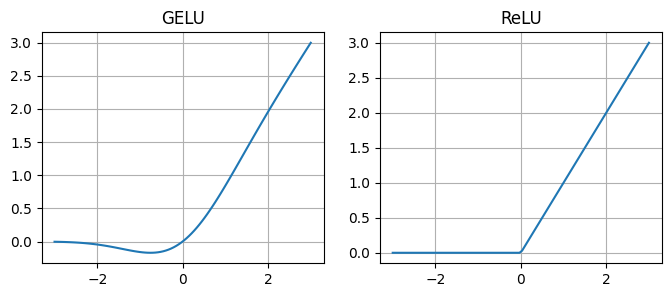

In [ ]:
import matplotlib.pyplot as plt
gelu,relu=GELU(),nn.ReLU()
x=torch.linspace(-3,3,100)
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(x,gelu(x))
plt.grid(True)
plt.title("GELU")
plt.subplot(1,2,2)
plt.plot(x,relu(x))
plt.title("ReLU")
plt.grid(True)


### FeedForward class

In [ ]:
# FEEDFORWARD CLASS
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers=nn.Sequential(nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
                              GELU(),
                              nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]))
  def forward(self,x):
    return self.layers(x)

###Config of GPT 2(124MP)

In [ ]:
GPT_CONFIG_124M={"vocab_size":50257,
                 "context_length":256,
                 "emb_dim":768,
                 "n_heads":12,
                 "n_layers":12,
                 "drop_rate":0.1,
                 "qkv_bias":False}

In [ ]:
ffn=FeedForward(GPT_CONFIG_124M)
x=torch.randn(2,3,768)
out=ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


###DeepNeuralNet Class

In [ ]:
#CREATING DEEPNEURAL NETWROK CLASS FOR SHORTCUT CONNECTIONS
class DeepNeuralNetwork(nn.Module):
  def __init__(self,laxer_sizes,use_shortcut):
    super().__init__()
    self.use_shortcut=use_shortcut
    self.laxers=nn.ModuleList([
        nn.Sequential(nn.Linear(laxer_sizes[0],laxer_sizes[1]),GELU()),
        nn.Sequential(nn.Linear(laxer_sizes[1],laxer_sizes[2]),GELU()),
        nn.Sequential(nn.Linear(laxer_sizes[2],laxer_sizes[3]),GELU()),
        nn.Sequential(nn.Linear(laxer_sizes[3],laxer_sizes[4]),GELU()),
        nn.Sequential(nn.Linear(laxer_sizes[4],laxer_sizes[5]),GELU())
    ])
  def forward(self,x):
    for i,laxer in enumerate(self.laxers):
      laxer_output=laxer(x)
      #print("laxer",i,"output is:",laxer_output)
      if self.use_shortcut and x.shape==laxer_output.shape:
        x+=laxer_output# x is not erased just another node in graph is created.
      else:
        x=laxer_output

    return x

In [ ]:
laxer_sizes=[3,5,3,4,3,2]
obj=DeepNeuralNetwork(laxer_sizes,use_shortcut=False)
sample_ip=torch.tensor([[1.0,-1.2,2.0]])
print(obj(sample_ip))

tensor([[0.0809, 0.2746]], grad_fn=<MulBackward0>)


###***Learning***

In [ ]:
# SEQUNETIAL VERSUS MODULELIST
model=nn.Sequential(nn.Linear(3,4),nn.ReLU())
ip=torch.randn(3)
print(model(ip))

tensor([0.8666, 0.0000, 0.0000, 1.0935], grad_fn=<ReluBackward0>)


In [ ]:
def cal_grad(model, x):
  output=model(x)
  target=torch.tensor([[0.]])
  loss=nn.MSELoss()
  loss=loss(output,target)
  x=loss.backward()
  for name,param in model.named_parameters():
    if 'weight' in name:
      print(f"{name} has gardeient mena of {param.grad.abs().mean().item()}")
print(cal_grad(obj,sample_ip))

laxers.0.0.weight has gardeient mena of 0.003285466693341732
laxers.1.0.weight has gardeient mena of 0.002654122421517968
laxers.2.0.weight has gardeient mena of 0.0019371839007362723
laxers.3.0.weight has gardeient mena of 0.013151324354112148
laxers.4.0.weight has gardeient mena of 0.014558094553649426
None


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [ ]:
# MODEL WITH SHORTCUT = TRUE
torch.manual_seed(123)
print(cal_grad(DeepNeuralNetwork(laxer_sizes,use_shortcut=True),sample_ip))

laxers.0.0.weight has gardeient mena of 0.0006834349478594959
laxers.1.0.weight has gardeient mena of 0.0006920021260157228
laxers.2.0.weight has gardeient mena of 0.0006531472317874432
laxers.3.0.weight has gardeient mena of 0.001063631265424192
laxers.4.0.weight has gardeient mena of 0.003998740576207638
None


#Coding Entire TransformerBlock

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift
    ################
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.044715*torch.pow(x,3))))
##############################################################
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.laxers=nn.Sequential(nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
                              GELU(),
                              nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]))
  def forward(self,x):
    return self.laxers(x)

#####################################################################
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiheadAttention(d_in=cfg["emb_dim"],d_out=cfg["emb_dim"],context_length=cfg["context_length"],num_heads=cfg["n_heads"],dropout=cfg["drop_rate"],qkv_bias=cfg["qkv_bias"])
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut=nn.Dropout(cfg["drop_rate"])



  def forward(self,x):
     shortcut=x
     x=self.norm1(x)
     x=self.att(x)
     x=self.drop_shortcut(x)
     x=x+shortcut
     shortcut=x
     x=self.norm2(x)
     x=self.ff(x)
     x=self.drop_shortcut(x)
     x=x+shortcut
     return x

torch.manual_seed(123)
x=torch.randn(2,4,768)
block=TransformerBlock(GPT_CONFIG_124M)
output=block(x)
print("Input shape:",x.shape)
print("Output shape:",output.shape)
print(output[1,:,:10])



Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
tensor([[ 0.5202,  1.1913, -1.1250, -0.4199,  1.3467, -1.1426, -0.5658,  1.8162,
          1.1068, -2.0083],
        [-0.4818, -1.2310, -0.5211, -3.2530, -0.3963, -1.6386,  0.6480, -0.3341,
          0.0628, -0.0966],
        [-1.4165, -0.4730, -0.5893, -0.0359,  2.3496,  0.6145, -1.0692, -0.6609,
         -0.4318, -0.4063],
        [-0.5516, -1.1597,  0.1533, -2.2510,  0.3653,  0.1009,  0.5654, -0.1593,
          0.9399, -0.5996]], grad_fn=<SliceBackward0>)


In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift
 #########################################################
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.044715*torch.pow(x,3))))
##############################################################
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers=nn.Sequential(nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
                              GELU(),
                              nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]))
  def forward(self,x):
    return self.layers(x)

#####################################################################
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiheadAttention(d_in=cfg["emb_dim"],d_out=cfg["emb_dim"],context_length=cfg["context_length"],num_heads=cfg["n_heads"],dropout=cfg["drop_rate"],qkv_bias=cfg["qkv_bias"])
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

  def forward(self,x):
    shortcut=x
    x=self.norm1(x)
    x=self.att(x)
    x=self.drop_shortcut(x)
    x=x+shortcut

    shortcut=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_shortcut(x)
    x=x+shortcut
    return x

torch.manual_seed(123)
x=torch.randn(2,4,768)
block=TransformerBlock(GPT_CONFIG_124M)
output=block(x)
print("Input shape:",x.shape)
print("Output shape:",len(output[1]))
print(output)



Input shape: torch.Size([2, 4, 768])
Output shape: 4
tensor([[[ 0.1924,  0.1151, -0.3698,  ..., -0.3268, -2.1495,  0.4935],
         [ 0.3960,  0.3342, -0.7922,  ..., -0.2489,  0.3978, -0.2880],
         [ 0.9321,  0.5151,  0.8996,  ..., -1.2020, -0.3262, -1.2914],
         [-0.0267,  2.1019, -2.2916,  ...,  0.6504, -1.4707, -0.7556]],

        [[ 0.5202,  1.1913, -1.1250,  ..., -0.5367,  0.3786,  0.3690],
         [-0.4818, -1.2310, -0.5211,  ...,  0.3366, -0.2602,  0.2491],
         [-1.4165, -0.4730, -0.5893,  ..., -0.1656, -1.0045,  1.1039],
         [-0.5516, -1.1597,  0.1533,  ..., -0.0375, -0.6273,  0.1853]]],
       grad_fn=<AddBackward0>)


#**GPTModel**

In [ ]:
class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])


    self.trf_blocks=nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm=LayerNorm(cfg["emb_dim"])
    self.out_head=nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)

  def forward(self,in_idx):
    batch_size,seq_length=in_idx.shape
    tok_embeds=self.tok_emb(in_idx)
    pos_embeds=self.pos_emb(torch.arange(seq_length,device=in_idx.device))
    x=tok_embeds+pos_embeds
    x=self.drop_emb(x)
    x=self.trf_blocks(x)
    x=self.final_norm(x)
    logits=self.out_head(x)
    return logits

torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)

# Correcting the batch tensor to have valid token IDs
batch = torch.tensor([[1234, 567, 42, 56], [43, 674, 1039, 46]]) # Replaced -1039 with a positive value 1039 (assuming it's within vocab_size)
seq_length = 4
model=GPTModel(GPT_CONFIG_124M)
out=model(batch)
print("input :",batch.shape)
print("output batch shape",out[:,-1,:])


input : torch.Size([2, 4])
output batch shape tensor([[-0.0051,  0.4987,  1.4228,  ...,  0.2938, -0.4443, -0.1222],
        [-0.5295, -0.2192,  0.2713,  ...,  0.3572, -0.1145,  0.0418]],
       grad_fn=<SelectBackward0>)


#Leaning *italicized text*

In [ ]:
# * upacking operator tounpack an iterbale [1,2,3] to 1,2,3
list={1,2,3,8,9,7}
print(list)
print(*list)
li=(['a','b','c','d','f'])
print(enumerate(list,0))
for i,al in zip(list,li):
  print(i,"->",al)

{1, 2, 3, 7, 8, 9}
1 2 3 7 8 9
1 -> a
2 -> b
3 -> c
7 -> d
8 -> f


In [ ]:
list=['a','b','c','d','e','f','g']
print(list[:-3])
torch.manual_seed(45)
box=torch.randn(2,4,3)
print(box)
max_vals=torch.max(box,dim=-1,keepdim=True)
max_vals_index=torch.argmax(box,dim=-1,keepdim=True)
x=torch.tensor(3.0,requires_grad=True) # Changed requires_grad to True
y=4*x*x
y.backward() # compute dy/dx
print(x.grad)

['a', 'b', 'c', 'd']
tensor([[[ 0.1371,  1.5252,  1.4718],
         [ 1.7016, -0.2837,  0.1012],
         [ 0.6574, -0.3337,  0.8709],
         [ 0.4470, -0.3503,  0.8977]],

        [[ 0.1323, -0.6716,  0.5089],
         [-1.2099, -1.0963, -1.6877],
         [ 0.9653,  0.2162, -0.8056],
         [ 1.5292,  0.8015, -0.7030]]])
tensor(24.)


# Predicting output

In [ ]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():# in order to dont have track of opns on tensors
      logits=model(idx_cond)
    logits=logits[:,-1,:]
    probs=torch.softmax(logits,dim=-1) # Removed keepdim=True
    idx_next=torch.argmax(probs,dim=-1,keepdim=True)
    idx=torch.cat((idx,idx_next),dim=1)
  return idx

In [ ]:
start_context="Hello, I am"
encoded=tokenizer.encode(start_context)
print("encoded:",encoded)
encoded_tensor=torch.tensor(encoded).unsqueeze(0)# shape from(3,) to (1,3)add one axis at front pos for (batch_szie,no_of_tokens)
print("encoded tensor shape:",encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded tensor shape: torch.Size([1, 4])


In [ ]:
model.eval()# shift model from training to testing mode
out=generate_text_simple(model=model,idx=encoded_tensor,max_new_tokens=6,context_size=GPT_CONFIG_124M["context_length"])
print(out)
print(len(out[0]))

tensor([[15496,    11,   314,   716,  8276,   967,  9180, 38454, 28860, 30695]])
10


In [ ]:
decoded_text=tokenizer.decode(out[0].tolist())# decode mthod should itake only 1d array
print(decoded_text)

Hello, I am somebodyork JaySprlocks378


In [ ]:
array=numpy.array([['a','b','c,','d','e','f','g']])
print(array[:,-4:])


[['d' 'e' 'f' 'g']]


#**Pre-training Phase** *italicized text*

##Loss Functions

In [ ]:
GPT_CONFIG_124MP={
    "vocab_size":50257,
    "context_length":256,
    "emb_dim":768,
    "n_heads":12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias":False
}
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124MP)



In [ ]:
import tiktoken
def text_to_token_ids(text,tokenizer):
  encoded=tokenizer.encode(text,allowed_special={'<|endoftext|>'})
  encoded_tensor=torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
  flat=token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

start_context="Every effort moves you"
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=generate_text_simple(model=model,idx=text_to_token_ids(start_context,tokenizer),max_new_tokens=10,context_size=GPT_CONFIG_124MP["context_length"])
print("output text:\n",token_ids_to_text(token_ids,tokenizer))
print(tokenizer.encode("every"))

output text:
 Every effort moves you Samoa parad Defensive MacBook Referospace preparation Einstein ShepherdMot
[16833]


In [ ]:
input=torch.tensor([[16833,3626,6100],#"every effort moves"
                    [40,1107,588]])#"i really like"

target=torch.tensor([[3626,6100,345],#"effort moves you"
                     [1107,588,11311]])#" really like chocolate"
with torch.no_grad():
  logits=model(input) # Changed 'inputs' to 'input'
probas=torch.softmax(logits,dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [ ]:
token_ids=torch.argmax(probas,dim=-1,keepdim=True)
print("Token ids with highest probability:\n",token_ids)

Token ids with highest probability:
 tensor([[[ 5873],
         [42899],
         [26729]],

        [[ 9580],
         [24016],
         [16637]]])


In [ ]:
print(f"Target for batch with index 0 :{token_ids_to_text(target[0],tokenizer)}")
print((f"Output predicted by model for batch with index 0:{token_ids_to_text(token_ids[0].flatten(),tokenizer)}"))

Target for batch with index 0 : effort moves you
Output predicted by model for batch with index 0: percentage Skinner Theme


In [ ]:
import torch
array=torch.tensor([[[1,2,3,4],[12,23,45,35],[56,77,89,54]],[[10,20,30,40],[44,44,33,22],[56,77,88,6]]]) # Corrected the second sub-list to have 3 inner lists
print(array.shape)
target=torch.tensor([[[0,1,1]],[[2,1,3]]])
print(target.shape)
new_one=array[1,[0,1,2],target[1]]
print(new_one)

torch.Size([2, 3, 4])
torch.Size([2, 1, 3])
tensor([[30, 44,  6]])


###Cross Entropy Loss

In [ ]:
print(logits.shape)
logits=logits.flatten(0,1)
print(logits.shape)#merged two batches from [2,3,50k] to [2*3=6, 50k]
print(target.shape)
target=target.flatten()
print(target)
print(target.shape)#merged target array into [6]

torch.Size([2, 3, 50257])
torch.Size([6, 50257])
torch.Size([2, 1, 3])
tensor([0, 1, 1, 2, 1, 3])
torch.Size([6])


In [ ]:
loss=torch.nn.functional.cross_entropy(logits,target)
print(loss)# this loss to be reduced to 0 or minimal possible

tensor(11.2210)


In [ ]:
# perplexity loss( way more for interpretibility)
perplexity_loss=torch.exp(loss)
print(perplexity_loss)

tensor(74682.5391)


#**LLM Training and Validation Loss**

In [ ]:
#JustKnowThings
import os
print(os.getcwd())
print(os.listdir())
print(os.path.exists("/content/drive/MyDrive/the-verdict.txt"))
print(os.path.isfile("/content/drive/MyDrive/Healthcare.zip"))
print(os.path.isdir("/content/drive/MyDrive/the-Verdict.txt"))
print(os.path.abspath("Sslcmarkscard.pdf"))
print(os.getppid())
os.listdir('/content/sample_data')

/content
['.config', 'drive', 'sample_data']
True
True
False
/content/Sslcmarkscard.pdf
85


['anscombe.json',
 'README.md',
 'california_housing_train.csv',
 'mnist_test.csv',
 'mnist_train_small.csv',
 'california_housing_test.csv']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.system("python --versison")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


512

In [ ]:
#JustKNowThings
data=b'Hello'
print(type(data))
print(data)
data_decoded=data.decode('utf-8')
print(type(data_decoded))
print(data_decoded)
print("a".encode('utf-8'))

<class 'bytes'>
b'Hello'
<class 'str'>
Hello
b'a'


In [ ]:
#Redaing a file or loading a file
import os
file_path=("/content/drive/MyDrive/the-verdict.txt")
with open(file_path,"r") as file:
  text_data=file.read()
#print(text_data)
print("Total characters :",len(text_data))
print(text_data[-99:])
print(len("helllo ganesh.!"))

Total characters : 20479
it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."
15


In [ ]:
#Genearting tokens for given file content
total_tokens=len(tokenizer.encode(text_data))
print("Total tokens generated by BPM :",total_tokens)
p=tokenizer.encode(text_data)
#print(tokenizer.encode(text_data).count(408))
##Counter
from collections import Counter
list=Counter(p)
print(type(p))
print(list)
#example 2
list=[22,34,34,34,56]
freq=Counter(list)
print(freq)
print(Counter("banana"))

Total tokens generated by BPM : 5145
<class 'list'>
Counter({11: 217, 13: 165, 198: 164, 262: 162, 284: 97, 286: 97, 438: 96, 314: 93, 257: 80, 373: 68, 290: 66, 340: 63, 339: 63, 465: 56, 326: 52, 1: 52, 550: 51, 287: 40, 616: 39, 338: 38, 12: 38, 502: 37, 683: 33, 351: 32, 470: 31, 366: 30, 40: 29, 319: 26, 423: 25, 345: 25, 526: 23, 530: 22, 271: 21, 10899: 21, 510: 21, 26: 21, 379: 21, 607: 21, 9074: 20, 25: 20, 764: 20, 402: 19, 520: 19, 5493: 19, 587: 18, 62: 18, 355: 18, 4808: 17, 407: 17, 0: 17, 673: 16, 416: 14, 523: 14, 531: 14, 3619: 13, 329: 13, 383: 12, 503: 12, 553: 12, 4286: 11, 477: 11, 281: 11, 910: 11, 30: 11, 655: 11, 766: 11, 546: 11, 475: 10, 307: 10, 618: 10, 1701: 10, 12036: 9, 2241: 9, 561: 9, 318: 9, 832: 9, 866: 9, 632: 9, 611: 9, 887: 9, 392: 9, 760: 9, 1544: 9, 1807: 8, 645: 8, 644: 8, 484: 8, 547: 8, 691: 8, 2951: 8, 588: 8, 292: 8, 1422: 8, 393: 7, 705: 7, 8759: 7, 2763: 7, 843: 7, 508: 7, 276: 7, 757: 7, 898: 7, 884: 7, 736: 7, 1234: 7, 422: 7, 612: 7, 29

In [ ]:
#Illustartion of Dataset class working(JKT)
from torch.utils.data import Dataset
class mydataset(Dataset):
  def __init__(self):
    self.x=[10,220,30,40]
    self.y=[0,1,1,5]
  def __len__(self):
    return len(self.x)
  def __getitem__(self,idx):
    return self.x[idx],self.y[idx]
obj=mydataset()
print(len(obj))
print(obj[3])

4
(40, 5)


In [ ]:
from torch.utils.data import Dataset,DataLoader

class GPTDatasetv1(Dataset):
  def __init__(self,txt,tokenizer,max_length,stride):
    self.input_ids=[]
    self.target_ids=[]
    token_ids=tokenizer.encode(txt,allowed_special={"<|endoftext|>:"})
    for i in range(0,len(token_ids)-max_length,stride):
      input_chunk=token_ids[i:i+max_length]
      target_chunk=token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)
  def __getitem__(self,idx):
    return self.input_ids[idx],self.target_ids[idx]

def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer=tiktoken.get_encoding("gpt2")
  dataset=GPTDatasetv1(txt,tokenizer,max_length,stride)
  dataloader=DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)
  return dataloader

#GPT config for this training purpose
GPT_CONFIG_124M={
                 "vocab_size":50257,
                 "context_length":256,
                 "emb_dim":768,
                 "n_heads":12,
                 "n_layers":12,
                 "drop_rate":0.1,
                 "qkv_bias":False}


In [ ]:
#Train / validation ratio
train_ratio=0.90
split_idx=int(train_ratio*len(text_data))
train_data=text_data[:split_idx]
val_data=text_data[split_idx:]
#print(train_data)
#print(":::::::::::::::::::::::::")
#print(val_data)
torch.manual_seed(123)
train_loader=create_dataloader_v1(train_data,batch_size=2,max_length=GPT_CONFIG_124MP["context_length"],stride=GPT_CONFIG_124MP["context_length"],drop_last=True,shuffle=True,num_workers=0)
val_loader=create_dataloader_v1(val_data,batch_size=2,max_length=GPT_CONFIG_124MP["context_length"],stride=GPT_CONFIG_124MP["context_length"],drop_last=False,shuffle=False,num_workers=0)
print(type(train_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [ ]:
print("Train laoder:")
for x,y in train_loader:
  print(x.shape,y.shape)
print("Validation loader")
for x,y in val_loader:
  print(x.shape,y.shape)


Train laoder:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Validation loader
torch.Size([2, 256]) torch.Size([2, 256])


In [ ]:
#usgage of numel() method
train_tokens=0
for input_batch,target_batch in train_loader:
  train_tokens+=target_batch.numel()
val_tokens=0
for input_batch,target_batch in val_loader:
  val_tokens+=target_batch.numel()
print("Training tokens",train_tokens)
print("validation tokens,",val_tokens)
print("Total tokens,",train_tokens+val_tokens)

Training tokens 4608
validation tokens, 512
Total tokens, 5120


In [ ]:
model=GPTModel(GPT_CONFIG_124MP)
model.eval()
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch,target_batch=input_batch.to(device),target_batch.to(device)
  logits=model(input_batch)
  #print(logits.shape)
  loss=torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())
  return loss
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0
  if len(data_loader)==0:
    return float("nan")
  elif num_batches is None:
    num_batches=len(data_loader)
  else:
    num_batches=min(num_batches,len(data_loader))
  for i,(input_batch,target_batch) in enumerate(data_loader):
    if i<num_batches:
      loss=calc_loss_batch(input_batch,target_batch,model,device)
      total_loss+=loss.item()
    else:
      break
  return total_loss/num_batches

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
with torch.no_grad():
  train_loss=calc_loss_loader(train_loader,model,device)
  val_loss=calc_loss_loader(val_loader,model,device)
print("Training loss:",train_loss)
print("Validation loss:",val_loss)


Training loss: 10.99884393480089
Validation loss: 10.997164726257324


**#Training the model**

In [ ]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
    val_loss=calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
  model.train()
  return train_loss, val_loss

In [ ]:
def generate_and_print_sample(model,tokenizer,device,start_context):
  model.eval()
  context_size=model.pos_emb.weight.shape[0]
  encoded=text_to_token_ids(start_context,tokenizer).to(device)
  with torch.no_grad():
    token_ids=generate_text_simple(model=model,idx=encoded,max_new_tokens=50,context_size=context_size)
  decoded_text=token_ids_to_text(token_ids,tokenizer)
  print(decoded_text.replace("\n"," "))
model.train()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiheadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_key): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiheadAttention(
        (w_query): Linear(in_features

In [ ]:
def train_model_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter,start_context,tokenizer):
  train_losses, val_losses,track_tokens_seen=[],[],[]
  tokens_seen,global_step=0,-1
  for epoch in range(num_epochs):
    model.train()

    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()
      loss=calc_loss_batch(input_batch,target_batch,model,device)
      loss.backward()
      optimizer.step()
      tokens_seen++input_batch.numel()
      global_step+=1

      if global_step % eval_freq==0:
        train_loss, val_loss=evaluate_model(model,train_loader,val_loader,device,eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Epoch{epoch+1} (step{global_step:06d}):" f"train loss{train_loss:.3f},val_loss{val_loss:.3f}")

    generate_and_print_sample(model,tokenizer,device,start_context)
  return train_losses, val_losses,track_tokens_seen

In [ ]:
# Main running code
import time
start_time=time.time()
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=0.004,weight_decay=0.1)


#num_epochs=10
#train_losses,val_losses,tokens_seen=train_model_simple(model,train_loader,val_loader,optimizer,device,num_epochs=num_epochs,eval_freq=5, eval_iter=5, start_context="Every Effort moves you",tokenizer=tokenizer)
#end_time=time.time()
#exe_time=(end_time-start_time)/60
#print(f"Training completet in {exe_time:.2f} minutes")
#

#**Decoding strategies to control randomness**

In [ ]:
model.to(device)
token_ids=generate_text_simple(model=model,idx=text_to_token_ids("Every Effort moves you",tokenizer).to(device),max_new_tokens=25,context_size=GPT_CONFIG_124M["context_length"])
print("Output text:",token_ids_to_text(token_ids,tokenizer))

Output text: Every Effort moves you Victim repercussions Vac sequentialIF see�nery MouthRogue TTAdvertisement expulsion caller 05ORT synaptic analogue Trail blasp Alberta LEGO fascinatingnutrition BG


In [ ]:
#tensor.item() method
x=torch.tensor(5)
print(type(x.item()))
print(type(x))
#for i in range(1_00):
  #print(i)

<class 'int'>
<class 'torch.Tensor'>


## Playing with temperature

In [ ]:
vocab={"closer":0,
       "every":1,
       "effort":2,
       "forward":3,
       "inches":4,
       "moves":5,
       "pizza":6,
       "toward":7,
       "you":8}
inverse_vocab={i:j for j,i in vocab.items()}
#print(inverse_vocab)
#just for sake of understanding consider the logits below
next_token_logits=torch.tensor([4.51,0.89,-1.90,6.75,1.63,-1.62,-1.89,6.28,1.79])
probas=torch.softmax(next_token_logits,dim=-1)
print(probas)
next_token_id=torch.argmax(probas).item()
print(next_token_id)
print(inverse_vocab[next_token_id])

tensor([0.0609, 0.0016, 0.0001, 0.5721, 0.0034, 0.0001, 0.0001, 0.3576, 0.0040])
3
forward


In [ ]:
model.to('cpu')

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiheadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_key): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiheadAttention(
        (w_query): Linear(in_features

In [ ]:
#replace argmax with multinomial fun
torch.manual_seed(123)
next_token_id=torch.multinomial(probas,num_samples=3,replacement=True)#num_samples can vary as per the no of tokens to be generated usually 1
print(next_token_id)
print([inverse_vocab[i] for i in next_token_id.tolist()])

tensor([3, 0, 3])
['forward', 'closer', 'forward']


In [ ]:
from collections import Counter
def print_sampled_tokens(probas):
  torch.manual_seed(123)
  sample=[torch.multinomial(probas,num_samples=1).item() for i in range(1_000)]
  freq=Counter(sample)
  print(freq)
print_sampled_tokens(probas)

Counter({3: 582, 7: 343, 0: 73, 4: 2})


In [ ]:
def softmax_with_temperature(logits,temperature):
  scaled_logits=logits/temperature
  return torch.softmax(scaled_logits,dim=0)# since logis=[] a id tensor dim=0
temperatures=[1,0.1,5]
scaled_probas=[softmax_with_temperature(next_token_logits,T) for T in temperatures]
print(scaled_probas)

[tensor([0.0609, 0.0016, 0.0001, 0.5721, 0.0034, 0.0001, 0.0001, 0.3576, 0.0040]), tensor([0.0000, 0.0000, 0.0000, 0.9910, 0.0000, 0.0000, 0.0000, 0.0090, 0.0000]), tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])]


In [ ]:
#Understanding torch.topk()
a=torch.tensor([[12,3,45,6,78],[123,45,31,56,8]])
# Original error: k=3 is out of range for dim=0 which has size 2.
# Corrected to find top 3 elements along dimension 1 (columns)
print(torch.topk(a,3,dim=1))

#ussage of torch.where(condition,val_if_cond_is_true,val_if_cond_is_false)
a_new=torch.where(a>20,2.0,1.0)
print(a_new)

torch.return_types.topk(
values=tensor([[ 78,  45,  12],
        [123,  56,  45]]),
indices=tensor([[4, 2, 0],
        [0, 3, 1]]))
tensor([[1., 1., 2., 1., 2.],
        [2., 2., 2., 2., 1.]])


In [ ]:
inf="-inf"
#print(inf<5)#error as inf is a string
inf=float("-inf")
print(inf<5)

True


## Temperature+top-k scaling

In [ ]:
def generate(model,idx,max_new_tokens,context_size,temperature=0.0,top_k=None,eos_id=None):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]

    if top_k is not None:
      # Debug print to inspect logits shape and top_k value
      #print(f"DEBUG in generate: logits shape: {logits.shape}, top_k: {top_k}")
      top_logits,_=torch.topk(logits,top_k)
      min_val=top_logits[:,-1].unsqueeze(-1)
      logits=torch.where(logits<min_val,torch.tensor(float("-inf")).to(logits.device),logits)

    if temperature>0.0:
      logits=logits/temperature
      probas=torch.softmax(logits,dim=-1)
      id_next=torch.multinomial(probas,num_samples=1)
    else:
      id_next=torch.argmax(logits,dim=-1,keepdim=True)
    if id_next==eos_id:
      break
    idx=torch.cat((idx,id_next),dim=1)
  return idx

In [ ]:
#testing the generate function
torch.manual_seed(123)
token_ids=generate(idx=text_to_token_ids("Every effort moves you",tokenizer),
                   model=model,
                   max_new_tokens=10,
                   context_size=GPT_CONFIG_124M["context_length"],
                   top_k=10,
                   temperature=0.2)
print("Output text:\n", token_ids_to_text(token_ids,tokenizer))

Output text:
 Every effort moves youEveryAPSObject promoting annexation analogous Scor Fiorina RenDetect


## Loading+saving pytorch model weights

In [ ]:
weights=model.state_dict()
print(weights["pos_emb.weight"].numel())

196608


In [ ]:
# Code to save model weights which have been processed so far.
import os
print(os.getcwd())
torch.save(model.state_dict(),"gpt2_weights.pth")
#print(torch.load("gpt2_weights.pth"))# just load sthe data into memory form disk
model.load_state_dict(torch.load("gpt2_weights.pth"))#puts weights automatically into model or loaded weights are copied into model

/content


<All keys matched successfully>

#Loading weights form OpenAI

In [ ]:
# Intro to Tesorflow frameworks
import tensorflow as tf
a=tf.constant([[[5.6],[3.5]]])
print(a)
b=tf.Variable([6])
print(f"Before varying the value {b.numpy()}")#use x.numpy() to get only values
print(type(b))
c=b.assign([67])
print(f"After varying the value {c.numpy()}")

tf.Tensor(
[[[5.6]
  [3.5]]], shape=(1, 2, 1), dtype=float32)
Before varying the value [6]
<class 'tensorflow.python.ops.resource_variable_ops.ResourceVariable'>
After varying the value [67]


In [ ]:
a=torch.tensor(6.0, requires_grad=True)
b=torch.tensor(a*3,requires_grad=True)
c=b*6
c.backward()
print(b.grad)


tensor(6.)


/tmp/ipykernel_4013/486122213.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b=torch.tensor(a*3,requires_grad=True)


In [ ]:
import tensorflow as tf
from tqdm import tqdm
print("Tensorflow version:",tf.__version__)
#print("tqdm version:",tqdm.__version__)


Tensorflow version: 2.19.0


In [ ]:
import time
print("Start",time.time())
for i in range(10):
  time.sleep(1)
print("end",time.time())

Start 1776180008.7049067
end 1776180018.7065377


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive')

In [ ]:
# actual code
from gpt_download3 import download_and_load_gpt2

settings, params = download_and_load_gpt2("124M", "models")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 67.8kiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.56MiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verifica

In [ ]:
print("Settings",settings)
print("parameter dictionary keys:",params.keys())
print(params["wte"])
print(params["wte"].shape)

Settings {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])
[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
(50257, 768)


In [ ]:
#Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})
gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.w_query.weight = assign(
            gpt.trf_blocks[b].att.w_query.weight, q_w.T)
        gpt.trf_blocks[b].att.w_key.weight = assign(
            gpt.trf_blocks[b].att.w_key.weight, k_w.T)
        gpt.trf_blocks[b].att.w_value.weight = assign(
            gpt.trf_blocks[b].att.w_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.w_query.bias = assign(
            gpt.trf_blocks[b].att.w_query.bias, q_b)
        gpt.trf_blocks[b].att.w_key.bias = assign(
            gpt.trf_blocks[b].att.w_key.bias, k_b)
        gpt.trf_blocks[b].att.w_value.bias = assign(
            gpt.trf_blocks[b].att.w_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [ ]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

In [ ]:

torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new set piece but only at times or for hours - at some periods on weekends on long break times during


In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Delhi is the most ", tokenizer).to(device),
    max_new_tokens=40,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=0.1 # Lowering the temperature for more coherent output
)

print("Output text with lower temperature:\n", token_ids_to_text(token_ids, tokenizer))

Output text with lower temperature:
 Delhi is the most  important city in India. It is home to the largest number of people in the world. It is also home to the largest number of people in the world. It is also home to the largest


In [ ]:
## Downloading dataset for finetuning

In [ ]:
#Spam dataset from  UC Irvine
!pip install ucimlrepo


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Extracting .tsv file from zip file
import zipfile

zip_path = "/content/drive/MyDrive/sms+spam+collection.zip"

#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    #print(zip_ref.namelist())

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extract("SMSSpamCollection", "/content/")

In [ ]:
data_file_path="/content/SMSSpamCollection"
import pandas as pd
df=pd.read_csv(data_file_path,sep="\t",header=None,names=["Label","SMS"])
df

,Label,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
print(df["Label"].value_counts())
df.shape
df["Label"].unique()

Label
ham     4825
spam     747
Name: count, dtype: int64


array(['ham', 'spam'], dtype=object)

In [ ]:
# Balancing dataset
import pandas as pd
def create_balanced_dataset(df):
  spam_samples=df[df["Label"]=="spam"]
  spam_samples_count=spam_samples["Label"].shape[0]
  ham_samples=df[df['Label']=='ham']
  ham_samples_subset=ham_samples.sample(spam_samples_count,random_state=45)
  balanced_df=pd.concat([spam_samples,ham_samples_subset])
  return balanced_df

balanced_df=create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())
balanced_df["Label"].unique()
#mapping ham->0 and spam->1
balanced_df["Label"]=balanced_df["Label"].map({"ham":0,"spam":1})
print(balanced_df["Label"])


Label
spam    747
ham     747
Name: count, dtype: int64
2       1
5       1
8       1
9       1
11      1
       ..
5225    0
1681    0
620     0
3604    0
4767    0
Name: Label, Length: 1494, dtype: int64


In [ ]:
# Splitting df into training,validation an dtesting set
def random_split(df,train_frac,val_frac):
  df=df.sample(frac=1,random_state=123).reset_index(drop=True)
  train_end=int(len(df)*train_frac)
  val_end=train_end+int(len(df)*val_frac)
  train_df=df[:train_end]
  val_df=df[train_end:val_end]
  test_df=df[val_end:]
  return train_df,val_df,test_df

train_df,validation_df,test_df=random_split(balanced_df,0.7,0.1)
print(len(test_df))


300


In [ ]:
#CONVERTING DFs INTO CSV FILES
train_df.to_csv("train.csv")
validation_df.to_csv("validation.csv")
test_df.to_csv("test.csv")

In [ ]:
data=pd.read_csv("train.csv")
data["SMS"]

,SMS
0,U have a secret admirer who is looking 2 make ...
1,We tried to contact you re your reply to our o...
2,"Nah, I'm a perpetual DD"
3,Its a great day. Do have yourself a beautiful ...
4,"Sorry, I'll call later in meeting"
...,...
1040,Who were those people ? Were you in a tour ? I...
1041,Nt yet chikku..simple habba..hw abt u?
1042,Watching tv lor. Nice one then i like lor.
1043,"Yes obviously, but you are the eggs-pert and t..."


## Dataloaders and Datasets

In [ ]:
#Dataset creation
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
  def __init__(self,csv_file,tokenizer,max_length=None,pad_token_id=50256):
    self.data=pd.read_csv(csv_file)
    self.encoded_texts=[tokenizer.encode(text) for text in self.data['SMS']]
    if max_length==None:
      self.max_length=self._longest_encoded_length()
    else:
      self.max_length=max_length
      self.encoded_texts=[encoded_text[:self.max_length] for encoded_text in self.encoded_texts]
    self.encoded_texts=[encoded_text+[pad_token_id]*(self.max_length-len(encoded_text)) for encoded_text in self.encoded_texts]

  def __getitem__(self,index):
    encoded=self.encoded_texts[index]
    label=self.data.iloc[index]["Label"]
    return (torch.tensor(encoded,dtype=torch.long),
            torch.tensor(label,dtype=torch.long))

  def __len__(self):
    return len(self.data)
  def _longest_encoded_length(self):
    max_len=0
    for encoded_text in self.encoded_texts:
      encoded_len=len(encoded_text)
      if encoded_len>max_len:
        max_len=encoded_len
    return max_len

train_dataset=SpamDataset(csv_file="train.csv",max_length=None,tokenizer=tokenizer)
print(train_dataset.max_length)

validation_dataset=SpamDataset(csv_file="validation.csv",max_length=train_dataset.max_length,tokenizer=tokenizer)
test_dataset=SpamDataset(csv_file="test.csv",max_length=None,tokenizer=tokenizer)
print(validation_dataset.max_length)
print(test_dataset.max_length)

188
188
169


## Dataloader Makeup

In [ ]:
from torch.utils.data import DataLoader
num_workers=0
batch_size=8
torch.manual_seed(123)
train_loader=DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True,num_workers=num_workers,drop_last=True)
val_loader=DataLoader(dataset=validation_dataset,batch_size=batch_size,shuffle=True,num_workers=num_workers,drop_last=True)
test_loader=DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=True,num_workers=num_workers,drop_last=True)

In [ ]:
print("Train loader:")
for input_batch,target_batch in train_loader:
  pass
print("Input batch dimensions:",input_batch.shape)
print("Label dimension:",target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 188])
Label dimension: torch.Size([8])


In [ ]:
for batch in train_loader:
  print(batch)
  print(len(batch))
  break

[tensor([[ 6214,   345,   612,  ..., 50256, 50256, 50256],
        [   40,   716,  1016,  ..., 50256, 50256, 50256],
        [44217,   986,  5648,  ..., 50256, 50256, 50256],
        ...,
        [ 1639,   389,   257,  ..., 50256, 50256, 50256],
        [16454,  1438,  2956,  ..., 50256, 50256, 50256],
        [ 4261,    38,  3525,  ..., 50256, 50256, 50256]]), tensor([0, 0, 0, 1, 1, 1, 0, 1])]
2


In [ ]:
print(f"Training bathces:{len(train_loader)}")
print(f"Validation batches:{len(val_loader)}")
print(f"Test batches:{len(test_loader)}")

Training bathces:130
Validation batches:18
Test batches:37


#**FINETUNING LLM FOR CLASSIFICATION**

##LOADIG WEIGHTS FROM OPENAI TO MODEL FINETUNIG ON SPAM CLASSIFICATION

In [ ]:
#LOADIG WEIGHTS FROM OPENAI TO MODEL FINETUNIG ON SPAM CLASSIFICATION
CHOOSE_MODEL="gpt2-small (124M)"
INPUT_PROMPT="every effort moves"
BASE_CONFIG={"vocab_size":50257,"context_length":1024,"drop_rate":0.0,"qkv_bias":True}
model_configs={"gpt2-small (124M)":{"emb_dim":768,"n_layers":12,"n_heads":12},
               "gpt2-medium (355M)":{"emb_dim":1024,"n_layers":24,"n_heads":16},
               "gpt2-large (774M)":{"emb_dim":1280,"n_layers":12*3,"n_heads":20},
               "gpt2-xl (1558M)":{"emb_dim":1600,"n_layers":48,"n_heads":25}
               }
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
assert train_dataset.max_length <=BASE_CONFIG["context_length"],(f"Dataset length {train_dataset.max_length} exceeds model's context"
f"length{BASE_CONFIG['context_length']}. reinitilaise data sets with"
f"max_length={BASE_CONFIG['context_length']}")

In [ ]:
model_size=CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
from gpt_download3 import download_and_load_gpt2
settings,params=download_and_load_gpt2(model_size=model_size,models_dir="gpt2")
model=GPTModel(BASE_CONFIG)
load_weights_into_gpt(model,params)
model.eval()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 153kiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.45MiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verificat

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiheadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=True)
        (w_key): Linear(in_features=768, out_features=768, bias=True)
        (w_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiheadAttention(
        (w_query): Linear(in_features=7

In [ ]:
model.eval()

text_1="Delhi is the capital of "

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=25,
    context_size=BASE_CONFIG["context_length"],
    top_k=50,
    temperature=0.1
)

print(token_ids_to_text(token_ids, tokenizer))

Delhi is the capital of  India, and is home to the largest number of Indian-origin students.
The number of Indian-origin students in


In [ ]:
print(model.parameters)

<bound method Module.parameters of GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiheadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=True)
        (w_key): Linear(in_features=768, out_features=768, bias=True)
        (w_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiheadAttention(
    

In [ ]:
#FREEZING ALL THE MODEL PARAMETERS EXCPET LAST LAYER ONE
for params in model.parameters():
  params.requires_grad=False
num_classes=2
model.out_head=torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"],out_features=num_classes)
for param in model.trf_blocks[-1].parameters():
  param.requires_grad=True
for param in model.final_norm.parameters():
  param.requires_grad=True

In [ ]:
#CHECKING IF THE OUTPUT HEAD HAS 2 VALUED TENSOR OR NOT
inputs=tokenizer.encode("Do you take tea")
inputs=torch.tensor(inputs).unsqueeze(0)
print("Inputs",inputs)
print("Dimension",inputs.shape)
with torch.no_grad():
  output=model(inputs)
print(output)
#Extracting last output row only
print("Last output token ",output[:,-1,:])


Inputs tensor([[5211,  345, 1011, 8887]])
Dimension torch.Size([1, 4])
tensor([[[0.0071, 1.4115],
         [5.6127, 6.9569],
         [4.2723, 4.4145],
         [2.8663, 4.9187]]])
Last output token  tensor([[2.8663, 4.9187]])


##CALCULATING LOSS

In [ ]:
#APPLYING SOFTMAX TO OUTPUT TOKEN
probas=torch.softmax(torch.tensor([17.90,19.80]),dim=-1)
print(probas)
label=torch.argmax(probas)
print(label)
print(label.shape)


tensor([0.1301, 0.8699])
tensor(1)
torch.Size([])


In [ ]:
print(train_loader)
for i,(inp,tar) in enumerate(test_loader):
  print(inp,tar,sep="!!")
  print(inp.shape)
  print(tar.shape)
  print(tar.numel())
  print(i)
  break



tensor([[   37,  2200,  3620,  ..., 50256, 50256, 50256],
        [   39, 12236,   986,  ..., 50256, 50256, 50256],
        [   52,   460, 25779,  ..., 50256, 50256, 50256],
        ...,
        [16692,  5236,   318,  ..., 50256, 50256, 50256],
        [35361,  8800,    13,  ..., 50256, 50256, 50256],
        [17250, 14373,    69,  ..., 50256, 50256, 50256]])!!tensor([1, 0, 1, 1, 0, 1, 1, 0])
torch.Size([8, 169])
torch.Size([8])
8
0


In [ ]:
#DEFINING ACCURACY FUCNTION FOR DIFF DATALOADERS
def calc_accuracy_loader(data_loader,model,device,num_batches=None):
  model.eval()
  correct_predictions,num_examples=0,0

  if num_batches is None:
    num_batches=len(data_loader)
  else:
    num_bathces=min(len(data_loader),num_batches)
  for i,(input_batch,target_batch) in enumerate(data_loader):
    if i<num_batches:
      input_batch,target_batch=input_batch.to(device),target_batch.to(device)
      with torch.no_grad():
        logits=model(input_batch)[:,-1,:]
      predicted_labels=torch.argmax(logits,dim=-1)
      num_examples+=predicted_labels.shape[0]
      correct_predictions+=(predicted_labels==target_batch).sum().item()
    else:
      break
  return correct_predictions/num_examples

In [ ]:
"""device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_accuracy=calc_accuracy_loader(train_loader,model,device,num_batches=10)
print("Training accuracy",train_accuracy)
val_accuracy=calc_accuracy_loader(val_loader,model,device,num_batches=10)
print("Training accuracy",val_accuracy)
test_accuracy=calc_accuracy_loader(test_loader,model,device,num_batches=10)
print("Training accuracy",test_accuracy)"""


Training accuracy 0.5375


KeyboardInterrupt: 

In [ ]:
#DEFINING LOSS FUNCTION
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch,target_batch=input_batch.to(device),target_batch.to(device)
  logits=model(input_batch)[:,-1,:]
  loss=torch.nn.functional.cross_entropy(logits,target_batch)
  return loss

In [ ]:
#DEFINIG LOSS FUNCTION TO LOADER LEVEL
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0.
  if len(data_loader)==0:
         return float("nan")
  elif num_batches is None:
    num_batches=len(data_loader)
  else:
    num_batches=min(len(data_loader),num_batches)
  for i,(input_batch,target_batch) in enumerate(data_loader):
    if i<num_batches:
      loss=calc_loss_batch(input_batch,target_batch,model,device)
      total_loss+=loss.item()
    else:
      break
  return total_loss/num_batches

In [ ]:
#COMPUTING LOSS FOR EACH LOADERS WITH 10 BATCHES INITIALISED
with torch.no_grad():
  train_loss=calc_loss_loader(train_loader,model,device,num_batches=5)
  val_loss=calc_loss_loader(val_loader,model,device,num_batches=5)
  test_loss=calc_loss_loader(test_loader,model,device,num_batches=5)
  print("Train loss for 2  batches",train_loss)
  print("val loss for 2  batches",val_loss)
  print("test loss for 2  batches",test_loss)


Train loss for 2  batches 0.9852540731430054
val loss for 2  batches 1.2197314262390138
test loss for 2  batches 0.8025691747665405


In [ ]:
def train_classifier_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter):
  train_losses,val_losses,train_accs,val_accs=[],[],[],[]
  examples_seen,global_step=0,-1

  for epoch in range(num_epochs):
    model.train()

    for input_batch,target_batvh in train_loader:
      optimizer.zero_grad()#reset gradient from previous batch
      loss=calc_loss_batch(input_batch,target_batch,model,device)
      loss.backward()#calculatedoLby doW
      optimizer.step()#update w
      examples_seen+=input_batch.shape[0]
      global_step+=1

      if global_step%eval_freq==0:
        train_loss,val_loss=evaluate_model(model,train_loader,val_loader,device,eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1} (Step {global_step:06d}):"
        f"Train loss {train_loss:.3f},val loss{val_loss:.3f}")
  train_accuracy=calc_accuracy_loader(train_loader,model,device,num_batches=eval_iter)
  val_accuracy=calc_accuracy_loader(val_loader,model,device,num_batches=eval_iter)
  print(f"Training accuracy:{train_accuracy*100:.2f}")
  print((f"Validatio accuracy:{val_accuracy*100:.2f}"))
  return train_losses,val_losses,train_accs,val_accs



In [ ]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
    val_loss=calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
  model.train()
  return train_loss,val_loss

##Testing trained and validation

In [ ]:
import time
start_time=time.time()
torch.manual_seed(123)
optmizer=torch.optim.Adam(model.parameters(),lr=5e-5,weight_decay=0.1)
num_epochs=5
train_losses,val_losses,train_accs,val_accs,examples_seen=train_classifier_simple(model,train_loader,val_loader,optimizer,device,num_epochs=num_epochs,eval_freq=50,eval_iter=5)
end_time=time.time()
execution_time=end_time-start_time/60
print("Trianing completed at ",execution_time,"minutes")

Epoch 1 (Step 000000):Train loss 1.034,val loss0.798
Epoch 1 (Step 000050):Train loss 0.752,val loss1.003
Epoch 1 (Step 000100):Train loss 1.251,val loss0.958
Epoch 2 (Step 000150):Train loss 0.944,val loss0.991
Epoch 2 (Step 000200):Train loss 1.078,val loss1.037
Epoch 2 (Step 000250):Train loss 0.908,val loss0.843
Epoch 3 (Step 000300):Train loss 1.139,val loss1.034
Epoch 3 (Step 000350):Train loss 0.987,val loss0.796
Epoch 4 (Step 000400):Train loss 0.765,val loss0.880


In [ ]:
torch.save(model.state_dict(),"review_classifier.pth")


In [ ]:
model_state_dict=torch.load("review_classifier.pth")
model.load_state_dict(model_state_dict)

<All keys matched successfully>